In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sys
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from config.config import DATA_TRAIN

In [7]:
df = pd.read_csv(DATA_TRAIN)
df.head()

,date,departure_station,arrival_station,avg_journey_duration,nb_planned_trains,nb_cancelled_trains,avg_delay_all_trains_arrival,departure_temp_mean,departure_precip_sum,departure_wind_max,...,year,month,season,temp_diff_route,is_extreme_wind_dep,is_heavy_rain_dep,is_extreme_wind_arr,is_heavy_rain_arr,delay_lag_1,delay_lag_12
0,2018-01,BELLEGARDE (AIN),PARIS LYON,162.0,259.0,3.0,7.531966,5.59,283.5,19.52,...,2018,1,4,1.56,0,1,1,1,5.465355,5.229186
1,2018-02,BELLEGARDE (AIN),PARIS LYON,162.0,233.0,0.0,5.082546,1.00,52.5,21.39,...,2018,2,4,0.19,0,0,0,0,7.531966,5.229186
2,2018-03,BELLEGARDE (AIN),PARIS LYON,162.0,254.0,3.0,4.097145,5.64,173.0,25.57,...,2018,3,1,1.12,0,1,0,1,5.082546,5.229186
3,2018-04,BELLEGARDE (AIN),PARIS LYON,163.0,231.0,85.0,2.061187,13.65,61.9,18.09,...,2018,4,1,1.00,0,0,0,0,4.097145,5.229186
4,2018-05,BELLEGARDE (AIN),PARIS LYON,163.0,234.0,63.0,10.779142,16.08,128.4,18.67,...,2018,5,1,0.16,0,1,0,0,2.061187,5.229186


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          519 non-null    str    
 1   departure_station             519 non-null    str    
 2   arrival_station               519 non-null    str    
 3   avg_journey_duration          519 non-null    float64
 4   nb_planned_trains             519 non-null    float64
 5   nb_cancelled_trains           519 non-null    float64
 6   avg_delay_all_trains_arrival  519 non-null    float64
 7   departure_temp_mean           519 non-null    float64
 8   departure_precip_sum          519 non-null    float64
 9   departure_wind_max            519 non-null    float64
 10  arrival_temp_mean             519 non-null    float64
 11  arrival_precip_sum            519 non-null    float64
 12  arrival_wind_max              519 non-null    float64
 13  year            

In [5]:
df.describe()

,avg_journey_duration,nb_planned_trains,nb_cancelled_trains,avg_delay_all_trains_arrival,departure_temp_mean,departure_precip_sum,departure_wind_max,arrival_temp_mean,arrival_precip_sum,arrival_wind_max,year,month,season,temp_diff_route,is_extreme_wind_dep,is_heavy_rain_dep,is_extreme_wind_arr,is_heavy_rain_arr,delay_lag_1,delay_lag_12
count,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000
mean,146.277457,307.745665,8.061657,5.987831,12.683622,88.370520,26.390520,12.473237,70.914258,32.647861,2021.895954,6.373796,2.470135,1.109961,0.090559,0.504817,0.171484,0.366089,5.927034,5.694209
std,33.817134,140.451124,18.250934,3.997555,6.360659,49.510661,9.232487,6.208852,34.663716,7.008038,2.475510,3.406071,1.121299,0.783591,0.287257,0.500459,0.377295,0.482199,3.942491,3.778814
min,0.000000,0.000000,0.000000,-0.135417,0.210000,3.800000,9.420000,-0.170000,3.700000,18.130000,2018.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,-0.135417,-0.135417
25%,113.000000,221.500000,0.000000,3.192952,6.925000,50.850000,18.335000,6.805000,44.400000,27.540000,2020.000000,3.000000,1.000000,0.505000,0.000000,0.000000,0.000000,0.000000,3.192952,3.231603
50%,163.000000,279.000000,2.000000,5.154367,12.690000,80.400000,25.540000,12.600000,70.800000,31.870000,2022.000000,6.000000,2.000000,0.930000,0.000000,1.000000,0.000000,0.000000,5.150388,4.955792
75%,173.000000,383.500000,7.000000,7.797498,18.800000,116.850000,33.055000,18.210000,93.250000,37.510000,2024.000000,9.000000,3.000000,1.590000,0.000000,1.000000,0.000000,1.000000,7.622461,7.058699
max,195.000000,709.000000,143.000000,23.980000,25.210000,283.500000,52.400000,23.530000,186.500000,51.980000,2026.000000,12.000000,4.000000,4.140000,1.000000,1.000000,1.000000,1.000000,23.980000,23.980000


Target Distribution Analysis

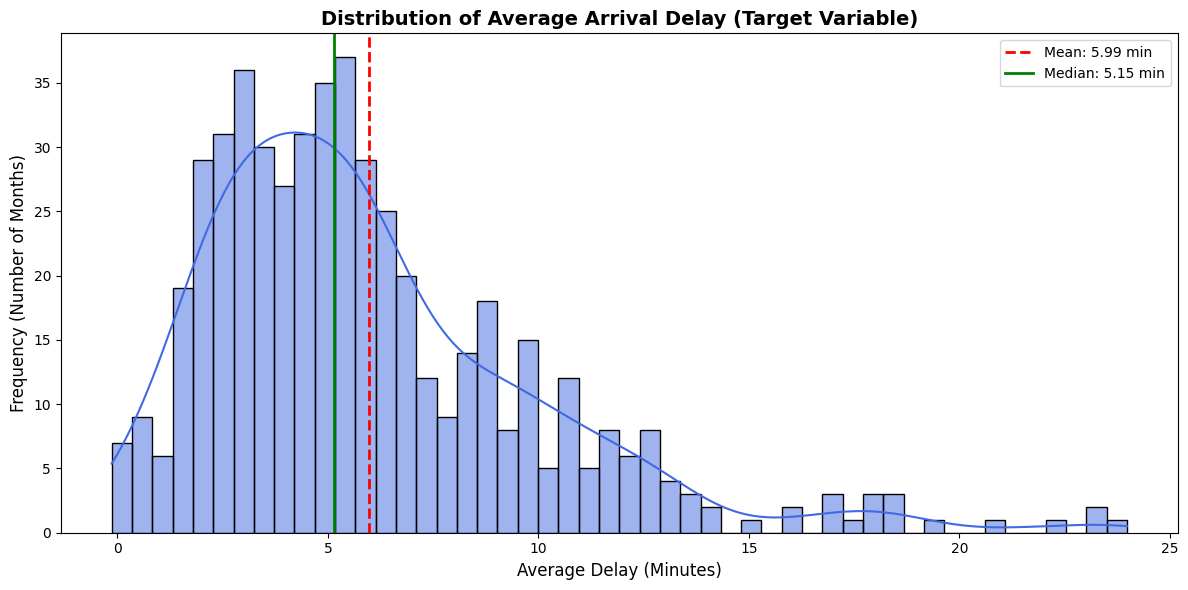

Skewness: 1.47
Insight: The data is heavily right-skewed. Applying a Log-Transformation (y' = log(y + 1)) in the pipeline could help the Regression model perform better.


In [8]:
plt.figure(figsize=(12, 6))

# Plot Histogram combined with Kernel Density Estimate (KDE)
ax = sns.histplot(df['avg_delay_all_trains_arrival'], bins=50, kde=True, color='royalblue')

# Highlight key statistical markers
mean_val = df['avg_delay_all_trains_arrival'].mean()
median_val = df['avg_delay_all_trains_arrival'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f} min')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f} min')

plt.title('Distribution of Average Arrival Delay (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Average Delay (Minutes)', fontsize=12)
plt.ylabel('Frequency (Number of Months)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Print Skewness metric
skewness = df['avg_delay_all_trains_arrival'].skew()
print(f"Skewness: {skewness:.2f}")
if skewness > 1:
    print("Insight: The data is heavily right-skewed. Applying a Log-Transformation (y' = log(y + 1)) in the pipeline could help the Regression model perform better.")

Evaluating Lag Features (System Inertia)

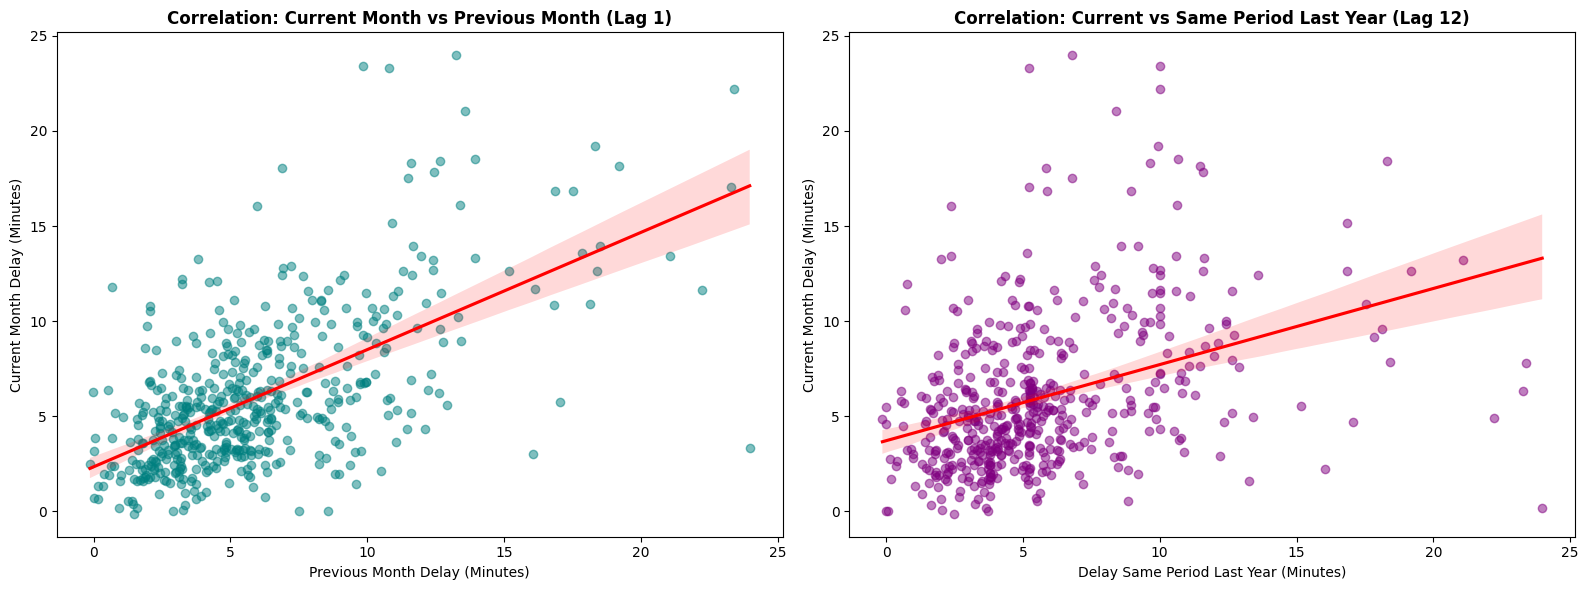

Pearson Linear Correlation:
- Lag 1 : 0.608
- Lag 12: 0.378


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for Lag 1
sns.regplot(data=df, x='delay_lag_1', y='avg_delay_all_trains_arrival', 
            ax=axes[0], scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Correlation: Current Month vs Previous Month (Lag 1)', fontweight='bold')
axes[0].set_xlabel('Previous Month Delay (Minutes)')
axes[0].set_ylabel('Current Month Delay (Minutes)')

# Scatter plot for Lag 12
sns.regplot(data=df, x='delay_lag_12', y='avg_delay_all_trains_arrival', 
            ax=axes[1], scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'red'})
axes[1].set_title('Correlation: Current vs Same Period Last Year (Lag 12)', fontweight='bold')
axes[1].set_xlabel('Delay Same Period Last Year (Minutes)')
axes[1].set_ylabel('Current Month Delay (Minutes)')

plt.tight_layout()
plt.show()

# Calculate Pearson Correlation coefficients
corr_lag1 = df[['delay_lag_1', 'avg_delay_all_trains_arrival']].corr().iloc[0, 1]
corr_lag12 = df[['delay_lag_12', 'avg_delay_all_trains_arrival']].corr().iloc[0, 1]
print(f"Pearson Linear Correlation:")
print(f"- Lag 1 : {corr_lag1:.3f}")
print(f"- Lag 12: {corr_lag12:.3f}")

Weather Impact Assessment

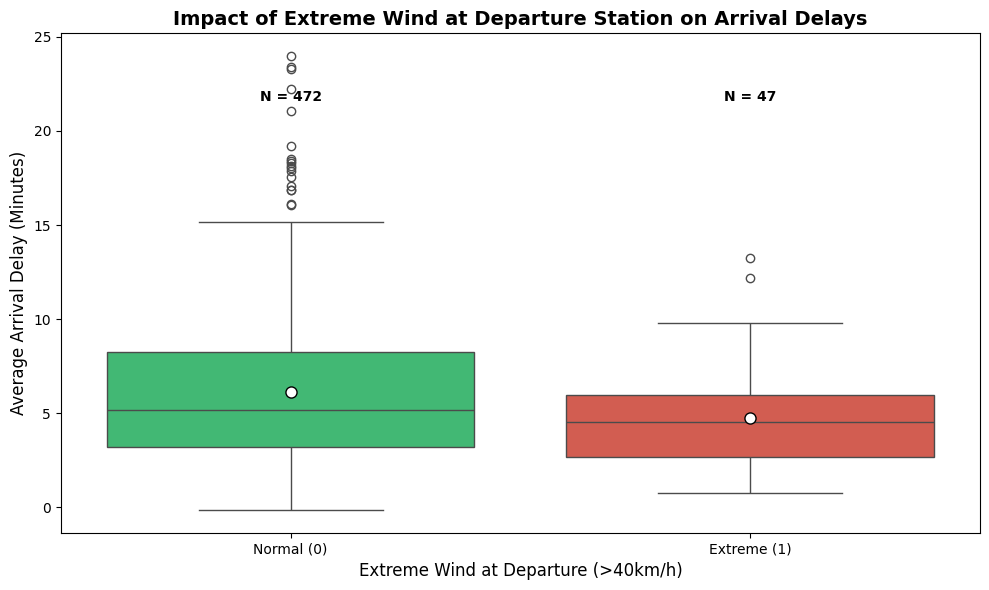

In [ ]:
plt.figure(figsize=(10, 6))

# Generate Boxplot
ax = sns.boxplot(data=df, x='is_extreme_wind_dep', y='avg_delay_all_trains_arrival', 
                 palette=['#2ecc71', '#e74c3c'], showmeans=True, 
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Impact of Extreme Wind at Departure Station on Arrival Delays', fontsize=14, fontweight='bold')
plt.xlabel('Extreme Wind at Departure (>40km/h)', fontsize=12)
plt.ylabel('Average Arrival Delay (Minutes)', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Extreme (1)'])

# Display observation count (N) for each group
obs_0 = df[df['is_extreme_wind_dep'] == 0].shape[0]
obs_1 = df[df['is_extreme_wind_dep'] == 1].shape[0]
ax.text(0, df['avg_delay_all_trains_arrival'].max()*0.9, f'N = {obs_0}', horizontalalignment='center', color='black', weight='semibold')
ax.text(1, df['avg_delay_all_trains_arrival'].max()*0.9, f'N = {obs_1}', horizontalalignment='center', color='black', weight='semibold')

plt.tight_layout()
plt.show()

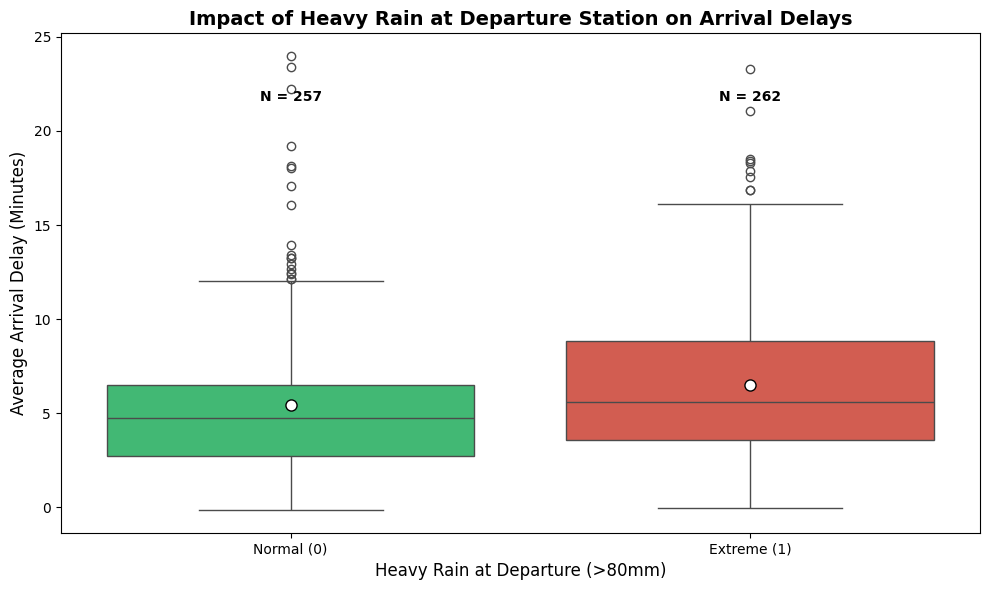

In [12]:
plt.figure(figsize=(10, 6))

# Generate Boxplot
ax = sns.boxplot(data=df, x='is_heavy_rain_dep', y='avg_delay_all_trains_arrival', 
                 palette=['#2ecc71', '#e74c3c'], showmeans=True, 
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Impact of Heavy Rain at Departure Station on Arrival Delays', fontsize=14, fontweight='bold')
plt.xlabel('Heavy Rain at Departure (>80mm)', fontsize=12)
plt.ylabel('Average Arrival Delay (Minutes)', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Extreme (1)'])

# Display observation count (N) for each group
obs_0 = df[df['is_heavy_rain_dep'] == 0].shape[0]
obs_1 = df[df['is_heavy_rain_dep'] == 1].shape[0]
ax.text(0, df['avg_delay_all_trains_arrival'].max()*0.9, f'N = {obs_0}', horizontalalignment='center', color='black', weight='semibold')
ax.text(1, df['avg_delay_all_trains_arrival'].max()*0.9, f'N = {obs_1}', horizontalalignment='center', color='black', weight='semibold')

plt.tight_layout()
plt.show()

Overall Correlation Matrix (Multicollinearity Check)

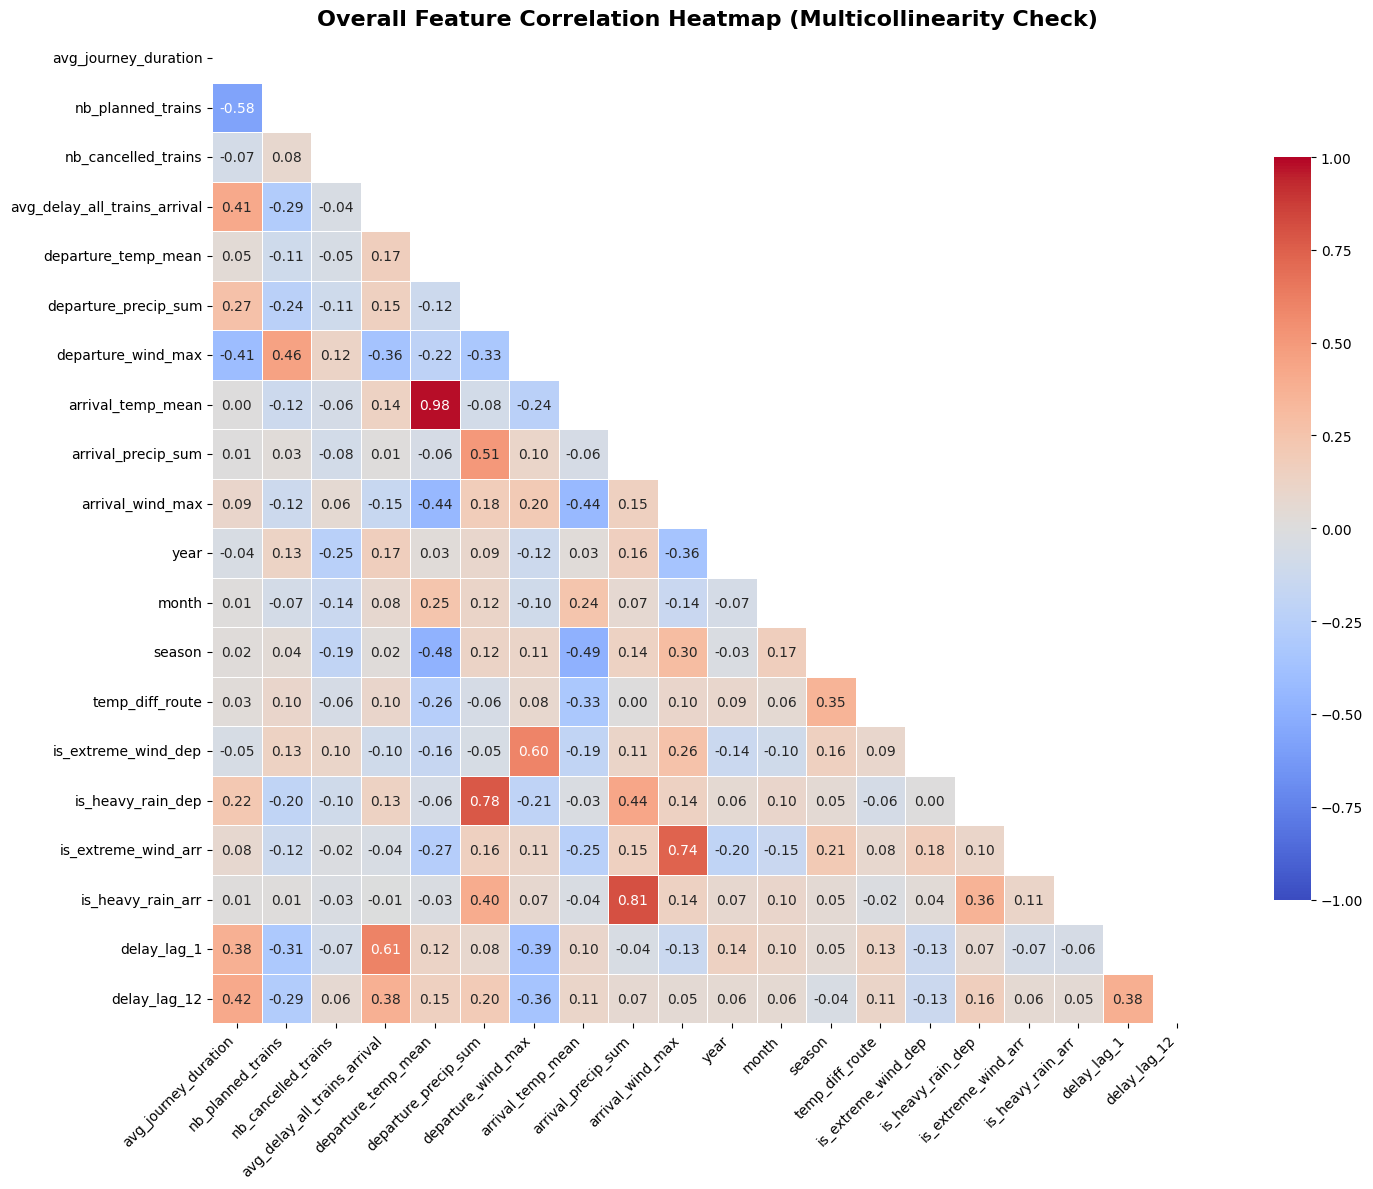

Top features with the highest absolute correlation to the Target:
delay_lag_1             0.607834
avg_journey_duration    0.414898
delay_lag_12            0.378369
departure_wind_max      0.362221
nb_planned_trains       0.287259
Name: avg_delay_all_trains_arrival, dtype: float64


In [11]:
# Isolate numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Set up a mask to show only the lower triangle (since the upper half is symmetrical)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Overall Feature Correlation Heatmap (Multicollinearity Check)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the top features most correlated with the Target
print("Top features with the highest absolute correlation to the Target:")
target_corr = corr_matrix['avg_delay_all_trains_arrival'].abs().sort_values(ascending=False)
print(target_corr[1:6]) # Skip the first row as it correlates with itself (1.0)

Time-Series Trend & Macro Events

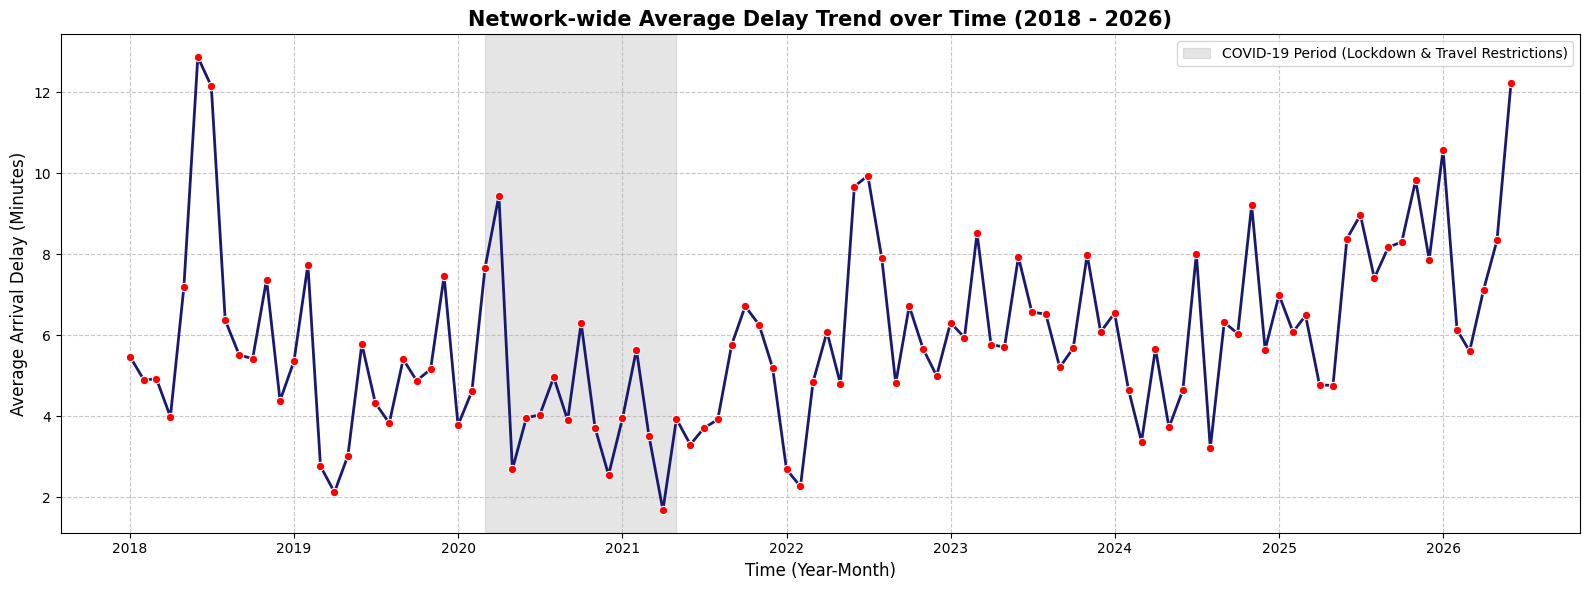

Insight: The chart reveals a significant drop in delays during the COVID-19 lockdown period due to reduced railway traffic. Additionally, sharp spikes typically align with winter cycles (December - January) or extreme summer heatwaves, confirming the necessity of the 'season' feature.


In [13]:
plt.figure(figsize=(16, 6))

# Ensure the date column is in datetime format for accurate X-axis plotting
df['date_dt'] = pd.to_datetime(df['date'])

# Calculate the average delay across all routes for each month
time_trend = df.groupby('date_dt')['avg_delay_all_trains_arrival'].mean().reset_index()

# Plot the Time-Series Line Chart
sns.lineplot(data=time_trend, x='date_dt', y='avg_delay_all_trains_arrival', 
             color='midnightblue', linewidth=2, marker='o', markersize=6, markerfacecolor='red')

# Highlight the COVID-19 period (Lockdowns significantly reduced train density and delays)
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-05-01'), 
            color='gray', alpha=0.2, label='COVID-19 Period (Lockdown & Travel Restrictions)')

plt.title('Network-wide Average Delay Trend over Time (2018 - 2026)', fontsize=15, fontweight='bold')
plt.xlabel('Time (Year-Month)', fontsize=12)
plt.ylabel('Average Arrival Delay (Minutes)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Insight: The chart reveals a significant drop in delays during the COVID-19 lockdown period due to reduced railway traffic. Additionally, sharp spikes typically align with winter cycles (December - January) or extreme summer heatwaves, confirming the necessity of the 'season' feature.")

Route-Specific Friction

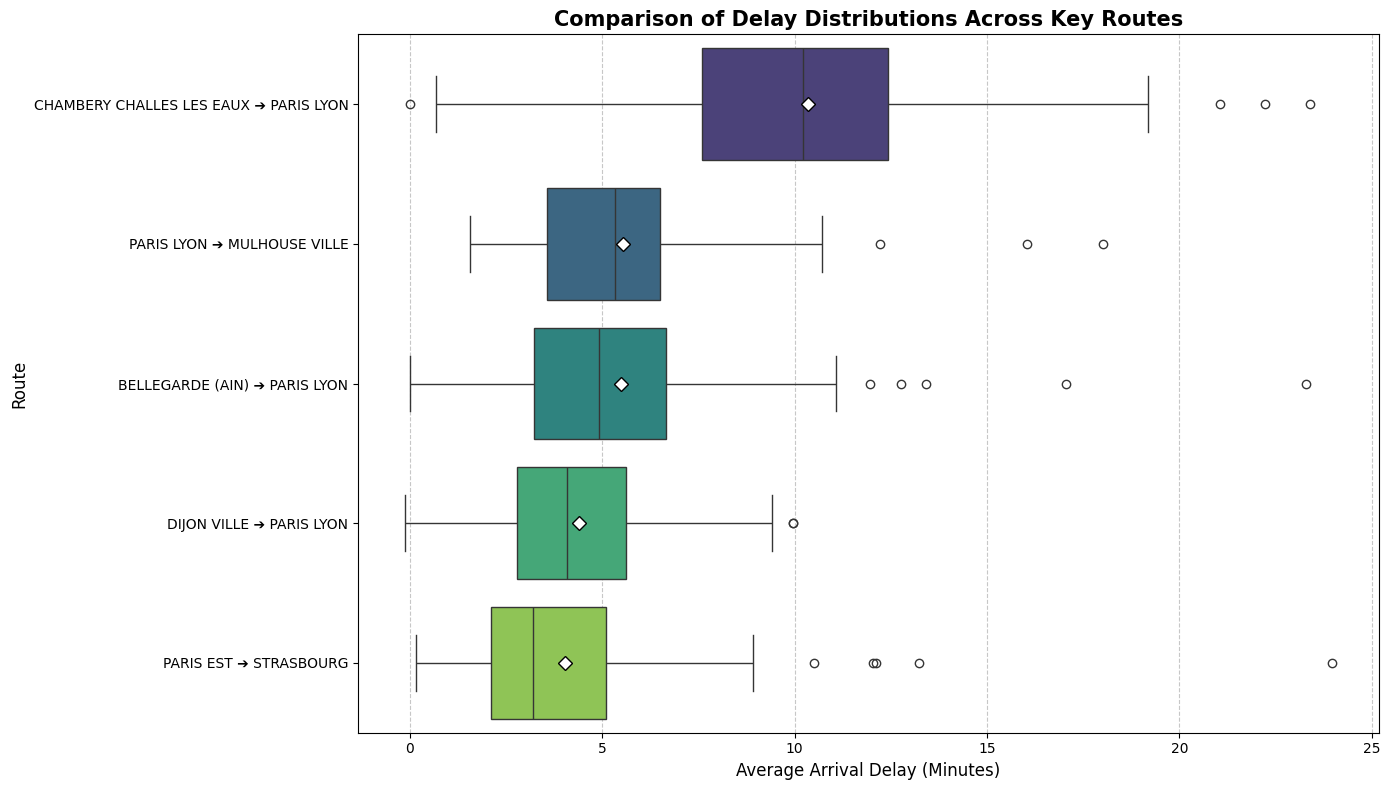

System Statistics:
Highest Risk Route: CHAMBERY CHALLES LES EAUX ➔ PARIS LYON
Most Stable Route: PARIS EST ➔ STRASBOURG

Insight: The distinct variations in delay distributions across routes highlight the impact of topography, journey length, and regional infrastructure. Predictive models will heavily leverage departure and arrival station data to assign appropriate spatial risk weights.


In [14]:
plt.figure(figsize=(14, 8))

# Create a combined Route feature for better readability on the chart
df['route_name'] = df['departure_station'] + ' ➔ ' + df['arrival_station']

# Order the routes by their median delay (from highest to lowest)
route_order = df.groupby('route_name')['avg_delay_all_trains_arrival'].median().sort_values(ascending=False).index

# Generate the Boxplot for Route Comparison
ax = sns.boxplot(data=df, y='route_name', x='avg_delay_all_trains_arrival', 
                 order=route_order, palette='viridis', showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"7"})

plt.title('Comparison of Delay Distributions Across Key Routes', fontsize=15, fontweight='bold')
plt.xlabel('Average Arrival Delay (Minutes)', fontsize=12)
plt.ylabel('Route', fontsize=12)

# Add a vertical grid to easily compare values across the x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Calculate and print quick descriptive statistics
riskiest_route = route_order[0]
safest_route = route_order[-1]
print(f"System Statistics:")
print(f"Highest Risk Route: {riskiest_route}")
print(f"Most Stable Route: {safest_route}")
print("\nInsight: The distinct variations in delay distributions across routes highlight the impact of topography, journey length, and regional infrastructure. Predictive models will heavily leverage departure and arrival station data to assign appropriate spatial risk weights.")